## Data preparation

Plate reader data is loaded using pr.load_platereader_data, which parses the raw instrument output and merges the platemap to annotate each well with its construct identity.

In [16]:
from cdk.analysis.cytosol import platereader as pr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.patches import Patch


warnings.filterwarnings('ignore')
pr.plot_setup()

In [5]:
# Load background-subtracted data
mango_data = pd.read_csv("../20251030_Aptamer_test_Mango_mScarlet/20251030_MangoTO1_mScarlet_data_background_sbtrk.csv")
mango_data["Time"] = pd.to_timedelta(mango_data["Time"])
mango_data["Experiment"] = "MangoIV"

broccoli_data = pd.read_csv("../20251027_Aptamer_test_Broccoli_mScarlet/20251027_Broccoli_mScarlet_data_Background_Sbtrkt.csv")
broccoli_data["Time"] = pd.to_timedelta(broccoli_data["Time"])
broccoli_data["Experiment"] = "Broccoli"

combined = pd.concat([mango_data, broccoli_data], ignore_index=True)
combined["Time (hours)"] = combined["Time"].dt.total_seconds() / 3600

print(f"MangoIV rows: {len(mango_data)}")
print(f"Broccoli rows: {len(broccoli_data)}")
print(f"Combined rows: {len(combined)}")
print(combined["Name"].unique())

MangoIV rows: 1980
Broccoli rows: 2160
Combined rows: 4140
['Negative' 'F30MangoIV-mScarlet' 'F30MangoIV-RiboJ-mScarlet'
 'tMangoIV-mScarlet' 'tMangoIV-RiboJ-mScarlet' 'F30-2xBroccoli-mScarlet'
 'F30-2xBroccoli-RiboJ-mScarlet' 'tdBroccoli-mScarlet'
 'tdBroccoli-RiboJ-mScarlet']


## Summary figure

A three-panel summary figure comparing transcription reporter quality across both aptamer systems and presenting the key biological result.

- **Panel 1 — Transcription reporter quality**: SNR plotted against lag CV (%) for all transcription reporter constructs on a log SNR scale. Each point represents a construct, coloured by reporter type (TO1-Biotin or DFHBI-1T). Points in the lower right represent optimal reporters with high SNR and low timing variability.

- **Panel 2 — Transcription reporter precision**: Lag CV (%) for all transcription reporter constructs grouped by reporter type. The dashed line indicates the 5% CV threshold below which timing measurements are considered sufficiently precise. Constructs are ordered by aptamer variant.

- **Panel 3 — Translation initiation delay**: The difference between the mScarlet lag time and the DFHBI-1T lag time for each Broccoli construct, representing the delay between detectable transcription onset and detectable translation onset. Error bars represent propagated standard deviation. Broccoli constructs only are shown as the MangoIV TO1-Biotin lag times are not sufficiently reliable for this comparison.

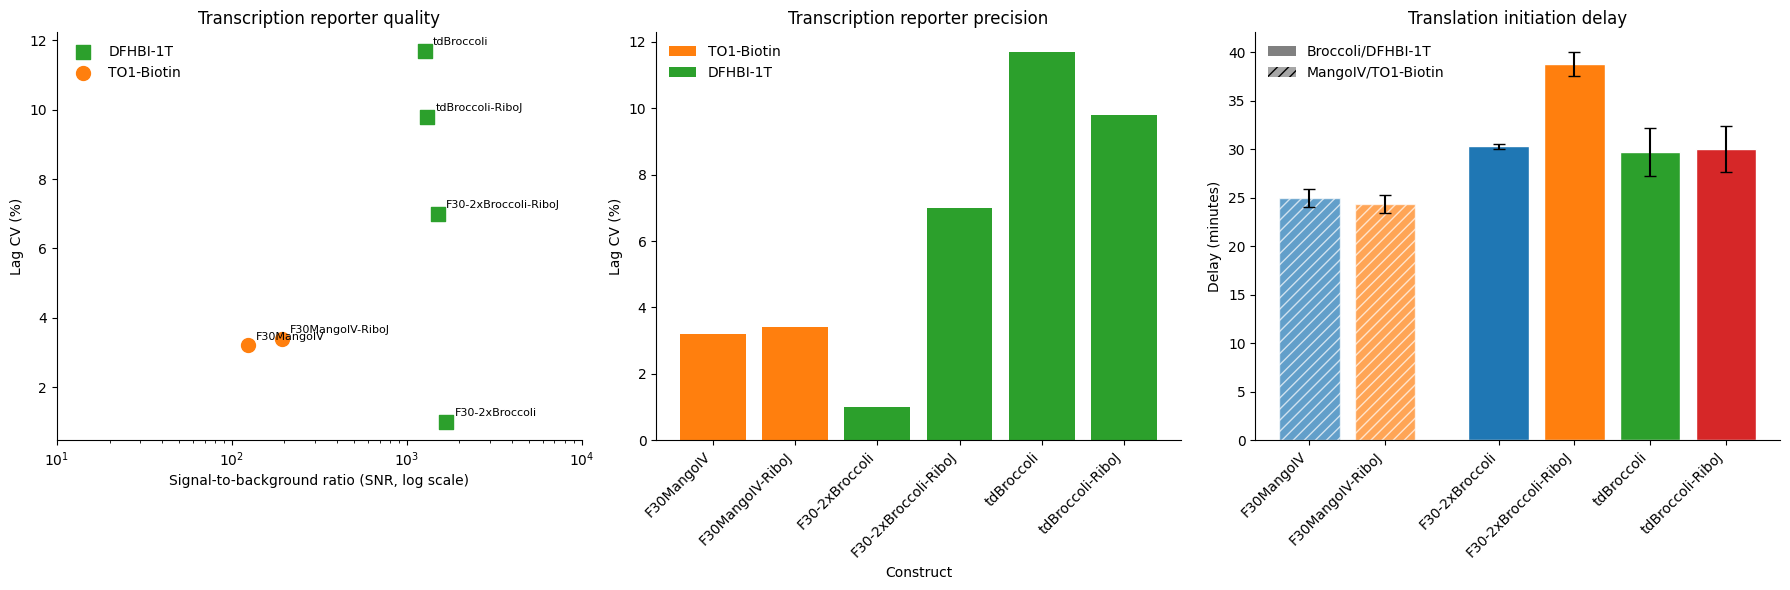

In [23]:
from matplotlib.patches import Patch

# Reorder constructs
construct_order_qc = [
    "F30MangoIV", "F30MangoIV-RiboJ",
    "F30-2xBroccoli", "F30-2xBroccoli-RiboJ",
    "tdBroccoli", "tdBroccoli-RiboJ"
]
qc_df["Construct"] = pd.Categorical(qc_df["Construct"], categories=construct_order_qc, ordered=True)
qc_df = qc_df.sort_values("Construct").reset_index(drop=True)

# Translation initiation delay for both experiments
mango_delay_mean = mango_mScarlet_mean - mango_TO1_mean
mango_delay_std = (mango_mScarlet_std**2 + mango_TO1_std**2)**0.5

mango_delay_df = pd.DataFrame({
    "Construct": mango_delay_mean.index.str.replace("-mScarlet", ""),
    "Delay (minutes)": mango_delay_mean.values,
    "Std": mango_delay_std.values,
    "Experiment": "MangoIV"
})

broccoli_delay_df = pd.DataFrame({
    "Construct": delay_mean.index.str.replace("-mScarlet", ""),
    "Delay (minutes)": delay_mean.values,
    "Std": delay_std.values,
    "Experiment": "Broccoli"
})

combined_delay_df = pd.concat([mango_delay_df, broccoli_delay_df], ignore_index=True)
combined_delay_df = combined_delay_df.dropna()

construct_order_delay = [
    "F30MangoIV", "F30MangoIV-RiboJ",
    "F30-2xBroccoli", "F30-2xBroccoli-RiboJ",
    "tdBroccoli", "tdBroccoli-RiboJ"
]
combined_delay_df["Construct"] = pd.Categorical(
    combined_delay_df["Construct"], categories=construct_order_delay, ordered=True
)
combined_delay_df = combined_delay_df.sort_values("Construct").reset_index(drop=True)

# Colour scheme
all_colours = {
    "F30MangoIV": "tab:blue",
    "F30MangoIV-RiboJ": "tab:orange",
    "F30-2xBroccoli": "tab:blue",
    "F30-2xBroccoli-RiboJ": "tab:orange",
    "tdBroccoli": "tab:green",
    "tdBroccoli-RiboJ": "tab:red",
}

# Three panel figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1 — SNR vs Lag CV scatter
palette = {"TO1-Biotin": "tab:orange", "DFHBI-1T": "tab:green"}
markers = {"TO1-Biotin": "o", "DFHBI-1T": "s"}
for reporter, group in qc_df.groupby("Reporter"):
    axes[0].scatter(group["SNR"], group["Lag CV (%)"],
                   color=palette[reporter], marker=markers[reporter],
                   s=100, label=reporter, zorder=3)
    for _, row in group.iterrows():
        axes[0].annotate(row["Construct"],
                        (row["SNR"], row["Lag CV (%)"]),
                        textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[0].set_xscale("log")
axes[0].set_xlim(10, 10000)
axes[0].set_xlabel("Signal-to-background ratio (SNR, log scale)")
axes[0].set_ylabel("Lag CV (%)")
axes[0].set_title("Transcription reporter quality")
axes[0].legend(title=None, frameon=False)

# Panel 2 — Lag CV bar plot
colours_p2 = [palette["TO1-Biotin"] if r == "TO1-Biotin" else palette["DFHBI-1T"]
              for r in qc_df["Reporter"]]
axes[1].bar(range(len(qc_df)), qc_df["Lag CV (%)"], color=colours_p2)
axes[1].set_xticks(range(len(qc_df)))
axes[1].set_xticklabels(qc_df["Construct"], rotation=45, ha="right")
axes[1].set_xlabel("Construct")
axes[1].set_ylabel("Lag CV (%)")
axes[1].set_title("Transcription reporter precision")
legend_elements_p2 = [
    Patch(facecolor="tab:orange", label="TO1-Biotin"),
    Patch(facecolor="tab:green", label="DFHBI-1T"),
]
axes[1].legend(handles=legend_elements_p2, frameon=False)

# Panel 3 — Translation initiation delay
x_positions = [0, 1, 2.5, 3.5, 4.5, 5.5]
for idx, (_, row) in enumerate(combined_delay_df.iterrows()):
    hatch = "///" if row["Experiment"] == "MangoIV" else ""
    axes[2].bar(x_positions[idx], row["Delay (minutes)"],
                color=all_colours.get(row["Construct"], "grey"),
                hatch=hatch, alpha=0.7 if hatch else 1.0,
                yerr=row["Std"], capsize=4, edgecolor="white", width=0.8)

axes[2].set_xticks(x_positions)
axes[2].set_xticklabels(combined_delay_df["Construct"], rotation=45, ha="right")
axes[2].set_ylabel("Delay (minutes)")
axes[2].set_title("Translation initiation delay")
legend_elements_p3 = [
    Patch(facecolor="grey", label="Broccoli/DFHBI-1T"),
    Patch(facecolor="grey", hatch="///", alpha=0.7, label="MangoIV/TO1-Biotin")
]
axes[2].legend(handles=legend_elements_p3, frameon=False)

sns.despine()
plt.tight_layout()
plt.savefig("./figures/summary_figure.png", dpi=600, bbox_inches="tight")
plt.show()

## Combined QC table

A unified QC table combining metrics from both the MangoIV and Broccoli experiments for all constructs and reporter combinations. Metrics are defined in the individual experiment notebooks. Note that tMangoIV TO1-Biotin lag times are not reported as no lag phase is detectable. † indicates a suspected construct label swap pending experimental confirmation.

In [24]:
# Build combined QC table
rows = []

# MangoIV constructs
mango_constructs = {
    "F30MangoIV-mScarlet": ("MangoIV", "TO1-Biotin", "Yes"),
    "F30MangoIV-RiboJ-mScarlet": ("MangoIV", "TO1-Biotin", "Yes"),
    "tMangoIV-mScarlet": ("MangoIV", "TO1-Biotin", "Yes*"),
    "tMangoIV-RiboJ-mScarlet": ("MangoIV", "TO1-Biotin", "No†"),
}

for construct, (experiment, aptamer_read, lag_detectable) in mango_constructs.items():
    clean_name = construct.replace("-mScarlet", "")
    has_lag = lag_detectable == "Yes"

    rows.append({
        "Experiment": experiment,
        "Construct": clean_name,
        "Reporter": aptamer_read,
        "Lag detectable": lag_detectable,
        "SNR": round(snr.loc[(experiment, construct, aptamer_read)], 2),
        "R²": round(mango_TO1_kinetics.loc[(construct, aptamer_read), "Fit"]["R^2"].mean(), 4) if has_lag else float("nan"),
        "Lag mean (min)": round(mango_TO1_mean.get(construct, 0), 1) if has_lag else "N/A",
        "Lag std (min)": round(mango_TO1_std.get(construct, 0), 1) if has_lag else "N/A",
        "Lag CV (%)": round(mango_TO1_std.get(construct, 0) / mango_TO1_mean.get(construct, 1) * 100, 1) if has_lag else "N/A",
        "Signal stability": round(stability.loc[(experiment, construct, aptamer_read)], 2),
    })

    rows.append({
        "Experiment": experiment,
        "Construct": clean_name,
        "Reporter": "mScarlet",
        "Lag detectable": "Yes",
        "SNR": round(snr.loc[(experiment, construct, "mScarlet")], 2),
        "R²": round(mango_mScarlet_kinetics.loc[(construct, "mScarlet"), "Fit"]["R^2"].mean(), 4),
        "Lag mean (min)": round(mango_mScarlet_mean.get(construct, 0), 1),
        "Lag std (min)": round(mango_mScarlet_std.get(construct, 0), 1),
        "Lag CV (%)": round(mango_mScarlet_std.get(construct, 0) / mango_mScarlet_mean.get(construct, 1) * 100, 1),
        "Signal stability": round(stability.loc[(experiment, construct, "mScarlet")], 2),
    })

# Broccoli constructs
broccoli_constructs = {
    "F30-2xBroccoli-mScarlet": ("Broccoli", "GFP-Gext"),
    "F30-2xBroccoli-RiboJ-mScarlet": ("Broccoli", "GFP-Gext"),
    "tdBroccoli-mScarlet": ("Broccoli", "GFP-Gext"),
    "tdBroccoli-RiboJ-mScarlet": ("Broccoli", "GFP-Gext"),
}

for construct, (experiment, aptamer_read) in broccoli_constructs.items():
    clean_name = construct.replace("-mScarlet", "")

    rows.append({
        "Experiment": experiment,
        "Construct": clean_name,
        "Reporter": "DFHBI-1T",
        "Lag detectable": "Yes",
        "SNR": round(snr.loc[(experiment, construct, aptamer_read)], 2),
        "R²": round(broccoli_aptamer_kinetics.loc[(construct, aptamer_read), "Fit"]["R^2"].mean(), 4),
        "Lag mean (min)": round(broccoli_aptamer_mean.get(construct, 0), 1),
        "Lag std (min)": round(broccoli_aptamer_std.get(construct, 0), 1),
        "Lag CV (%)": round(broccoli_aptamer_std.get(construct, 0) / broccoli_aptamer_mean.get(construct, 1) * 100, 1),
        "Signal stability": round(stability.loc[(experiment, construct, aptamer_read)], 2),
    })

    rows.append({
        "Experiment": experiment,
        "Construct": clean_name,
        "Reporter": "mScarlet",
        "Lag detectable": "Yes",
        "SNR": round(snr.loc[(experiment, construct, "mScarlet")], 2),
        "R²": round(broccoli_mScarlet_kinetics.loc[(construct, "mScarlet"), "Fit"]["R^2"].mean(), 4),
        "Lag mean (min)": round(broccoli_mScarlet_mean.get(construct, 0), 1),
        "Lag std (min)": round(broccoli_mScarlet_std.get(construct, 0), 1),
        "Lag CV (%)": round(broccoli_mScarlet_std.get(construct, 0) / broccoli_mScarlet_mean.get(construct, 1) * 100, 1),
        "Signal stability": round(stability.loc[(experiment, construct, "mScarlet")], 2),
    })

combined_qc_table = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(combined_qc_table)

print("\n* tMangoIV TO1-Biotin lag detectable at ~2 min after background subtraction but with high CV (30%) — interpret with caution.")
print("† tMangoIV-RiboJ TO1-Biotin: no lag phase detectable. Construct label swap suspected — repeat experiment pending.")

   Experiment             Construct    Reporter Lag detectable      SNR   R² Lag mean (min) Lag std (min) Lag CV (%)  Signal stability
0     MangoIV            F30MangoIV  TO1-Biotin            Yes   123.50 0.99          23.40          0.70       3.20              0.95
1     MangoIV            F30MangoIV    mScarlet            Yes 49194.82 1.00          48.40          0.60       1.20              0.98
2     MangoIV      F30MangoIV-RiboJ  TO1-Biotin            Yes   192.84 1.00          23.10          0.80       3.40              0.94
3     MangoIV      F30MangoIV-RiboJ    mScarlet            Yes 70179.87 1.00          47.40          0.50       1.10              1.02
4     MangoIV              tMangoIV  TO1-Biotin           Yes*   334.00  NaN            N/A           N/A        N/A              0.98
5     MangoIV              tMangoIV    mScarlet            Yes 66723.22 1.00          49.70          1.00       2.10              0.97
6     MangoIV        tMangoIV-RiboJ  TO1-Biotin        